# Root-Cause Analysis

## Top Sensors to Inspect

`sensor_059` is the top root-cause candidate: it leads on mean absolute SHAP (0.010) by a wide margin, so the model relies on it more than any other sensor to predict failure. Yet its SPC flag rate is 0% — no test wafer's reading on `sensor_059` ever crosses the ±3σ control limits set by the passing training population. A traditional Statistical Process Control chart on this sensor would never alarm.

This result diverges from the EDA in notebook 02, which ranked `sensor_103` first by both point-biserial correlation (r = 0.156) and standardized mean shift (Cohen's d ≈ 0.58), with `sensor_059` second. The model reverses that order: `sensor_059` leads on SHAP by roughly 40% over `sensor_033`, while `sensor_103` places third. Univariate correlation measures how strongly one sensor separates pass from fail in isolation; SHAP measures how much the model actually relies on each sensor given everything else it knows. The two questions have different answers here.

The first inspection set, ranked by model attribution, is `sensor_059`, `sensor_033`, `sensor_103`, `sensor_031`, and `sensor_129`. These sensors form the first inspection set for engineering follow-up.

## How the Ranking Was Derived

Three signals drawn from the trained model and the process data drive the analysis.

**Mean absolute SHAP** is the primary ranking signal. It measures how much a sensor shifts the model's predicted failure probability, on average across all test wafers. A high value means the model actively relies on that sensor when assigning risk.

**SHAP lift** *(supplementary)* is the difference in mean SHAP between failing and passing wafers. A positive value means the model specifically links that sensor's readings to failure, not just to general variability — it sharpens the question from "does the model use this sensor?" to "does the model blame this sensor when a wafer fails?"

**SPC flag rate** *(supplementary)* is the fraction of test wafers whose reading falls outside the ±3σ control limits computed from the stable passing training population. It shows which model-identified sensors are already caught by existing process monitoring and which are not. A high-SHAP sensor with a 0% SPC flag rate is invisible to classical control charts but central to the model.

Sensors are ranked by mean absolute SHAP alone. The supplementary signals are context for engineering judgment, not inputs to the ranking.

## Data and Model Context

The analysis uses the selected model from notebook 03 (`models/selected_model.joblib`, a tuned random forest classifier) and the raw train/test splits. The test set contains 236 wafers; the pipeline consumes all 590 raw sensor columns and retains 242 of them inside its `SecomPreprocessor` step. Notebook 03 set the cost-tuned threshold to favour recall; the ranked sensors below are the first inspection set for process engineering.

In [1]:
from __future__ import annotations

import contextlib
import io
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from yield_risk.config import load_config
from yield_risk.explainability import compute_shap_values, global_feature_importance, save_shap_values
from yield_risk.root_cause import fail_shap_lift, rank_root_cause_candidates, spc_flag_rate

In [2]:
cfg = load_config(ROOT / "configs" / "config.yaml")

model_path = ROOT / "models" / "selected_model.joblib"
train_path = ROOT / "data" / "splits" / "train.csv"
test_path = ROOT / "data" / "splits" / "test.csv"

required_paths = [model_path, train_path, test_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Model and split data artifacts are required. Missing: "
        + ", ".join(str(path) for path in missing_paths)
    )

pipeline = joblib.load(model_path)
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# The pipeline carries its own SecomPreprocessor, so it consumes the raw
# sensor columns directly; feature selection and imputation happen inside.
sensor_cols = [column for column in test.columns if column.startswith("sensor_")]
if not sensor_cols:
    raise ValueError("No sensor_* columns found in split test data.")

X_train = train[sensor_cols]
X_test = test[sensor_cols]
y_test = test["label"].to_numpy()

print(f"Loaded selected model: {model_path}")
print(f"Classifier: {type(pipeline.named_steps['classifier']).__name__}")
print(
    f"Train rows: {len(train):,}; test rows: {len(test):,}; "
    f"raw sensors: {len(sensor_cols):,}"
)

Loaded selected model: C:\Users\Virgil\Code\semiconductor-yield-root-cause\models\selected_model.joblib
Classifier: RandomForestClassifier
Train rows: 1,331; test rows: 236; raw sensors: 590


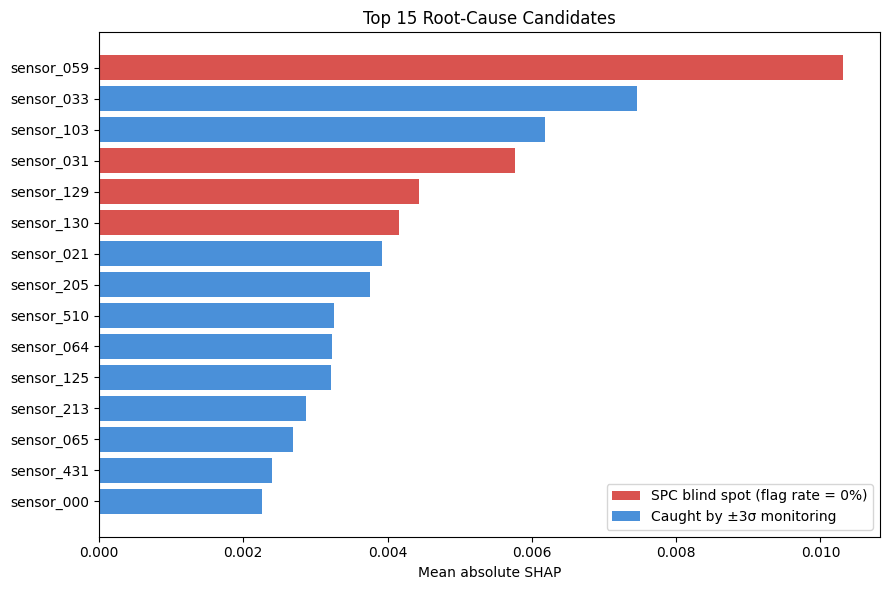

In [3]:
shap_stdout = io.StringIO()
with contextlib.redirect_stdout(shap_stdout), contextlib.redirect_stderr(shap_stdout):
    explanations = compute_shap_values(pipeline, X_train, X_test)
global_importance = global_feature_importance(explanations)
train_pass = train[train["label"] == 0]
flag_rates = spc_flag_rate(test, sensor_cols, reference=train_pass)
shap_lift = fail_shap_lift(explanations, y_test)
candidates = rank_root_cause_candidates(global_importance, shap_lift, flag_rates)

top = candidates.head(15).sort_values("mean_abs_shap")
colors = ["#d9534f" if v == 0.0 else "#4a90d9" for v in top["spc_flag_rate"]]

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["sensor"], top["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean absolute SHAP")
ax.set_title("Top 15 Root-Cause Candidates")
ax.legend(
    handles=[
        Patch(facecolor="#d9534f", label="SPC blind spot (flag rate = 0%)"),
        Patch(facecolor="#4a90d9", label="Caught by ±3σ monitoring"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

## Distribution Review

The top-ranked sensors tell different stories once the SPC flag rate is read alongside the model attribution.

`sensor_059` leads on mean absolute SHAP (0.010) by a wide margin — roughly 40% above the second sensor — and carries the largest positive fail/pass SHAP lift (0.019), so the model both relies on it and specifically blames it on failing wafers. Its SPC flag rate is 0%. No test wafer's reading ever crossed the ±3σ control limits defined by the passing training population, so a traditional SPC chart on `sensor_059` would never alarm. The model relies on this sensor more than any other, and classical process control would miss it entirely. This is the central finding: the ML approach surfaces a signal that ±3σ monitoring does not.

A 0% SPC flag rate has a concrete meaning. The readings on failing wafers sit inside the normal range as defined by the passing population — the failure signal is not an extreme excursion but a subtler pattern in a region SPC already considers normal. SPC asks "is this reading out of bounds?"; the model asks "given everything, does this reading shift the failure probability?" The two questions diverge precisely here.

`sensor_033` places second on SHAP magnitude (0.007), followed by `sensor_103` (0.006), `sensor_031` (0.006), and `sensor_129` (0.004). `sensor_031` carries a slightly negative SHAP lift (-0.002), a reminder that lift sign and attribution magnitude are distinct readings of the same sensor. `sensor_031` and `sensor_129` also show 0% SPC flag rates, so the SPC-blind-spot pattern is not unique to the leader.

For contrast, sensors such as `sensor_433` (SPC flag rate 0.051) and `sensor_572` (0.055) carry the highest SPC flag rates in the table but much lower SHAP attribution. SPC would alert on those, yet the model treats them as weaker failure candidates — the mirror image of `sensor_059`. The distribution plots below compare pass and fail densities directly for the top candidates.

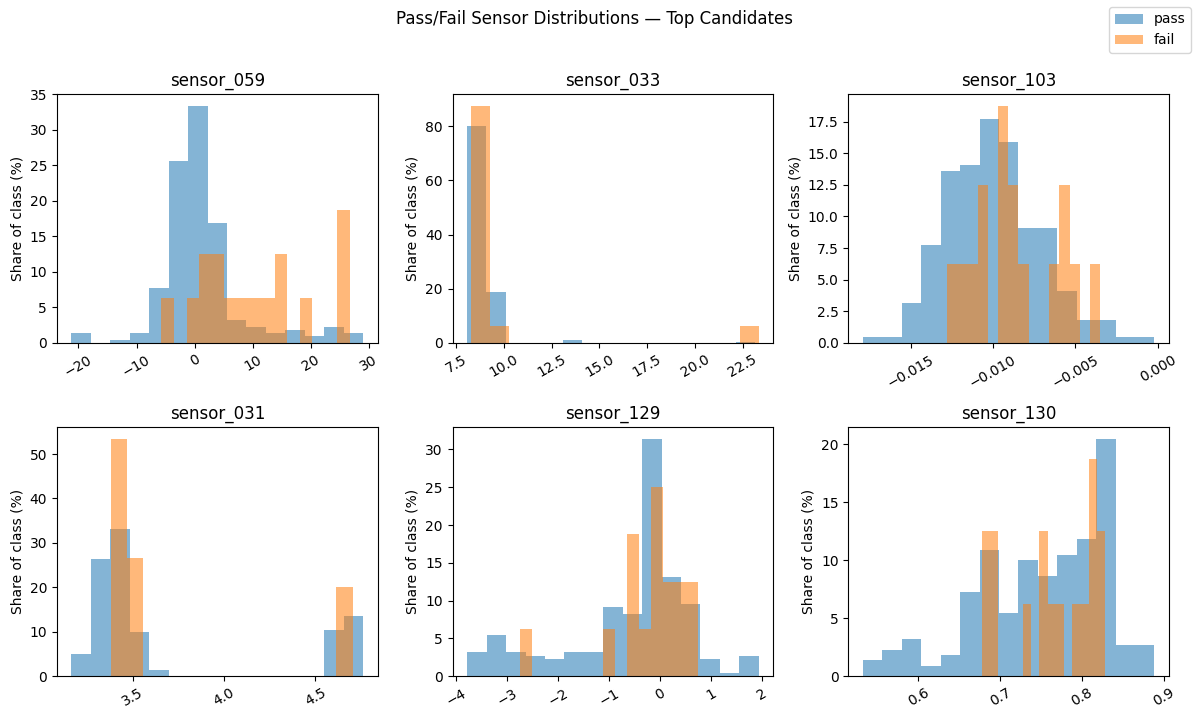

In [4]:
sensors_to_plot = candidates.head(6)["sensor"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, sensor in zip(axes.ravel(), sensors_to_plot, strict=False):
    passing = test.loc[test["label"] == 0, sensor].dropna()
    failing = test.loc[test["label"] == 1, sensor].dropna()
    ax.hist(passing, bins=15, alpha=0.55, label="pass",
            weights=[100 / len(passing)] * len(passing))
    ax.hist(failing, bins=15, alpha=0.55, label="fail",
            weights=[100 / len(failing)] * len(failing))
    ax.set_title(sensor)
    ax.set_ylabel("Share of class (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=30)

for ax in axes.ravel()[len(sensors_to_plot):]:
    ax.axis("off")

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Pass/Fail Sensor Distributions — Top Candidates", y=1.02)
plt.tight_layout()

## Persisted Review Artifacts

The SHAP values, global SHAP importance, and ranked root-cause candidate table are stored in `reports/`. These artifacts preserve the exact attribution results used in this report and provide the tabular inputs for follow-up process analysis.

In [5]:
reports_dir = ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

save_shap_values(explanations, reports_dir / "shap_values.npz")
global_importance.to_csv(reports_dir / "shap_global_importance.csv", index=False)
candidates.to_csv(reports_dir / "root_cause_candidates.csv", index=False)

print(f"Saved review artifacts to {reports_dir}")

Saved review artifacts to C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports


## What to Check Next

The root-cause analysis aligns with the sensor-importance rankings from notebook 03 and agrees across two independent attribution methods. The random forest impurity importance and the SHAP global ranking both place `sensor_059`, `sensor_033`, and `sensor_103` at the very top, with `sensor_031` and `sensor_129` also appearing high in both views. That cross-method agreement strengthens their value as the first sensors to inspect.

The next engineering step is to map `sensor_059`, `sensor_033`, `sensor_103`, `sensor_031`, and `sensor_129` to process step, tool, chamber, recipe, lot, and maintenance context. Because SECOM sensor IDs are anonymous and the label is binary pass/fail, process changes should wait until the leading sensor set is connected to fab context and checked for persistence across time, lots, tools, or chambers.